In [1]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

In [2]:
# 1. 파일 경로 설정
cems_path = '/data/personal_data/project_water_bodies_detection/Iran/labeled_data/Iran_labeled_data_clipped.tif'
digitized_path = '/data/personal_data/project_water_bodies_detection/Iran/labeled_data/ground_truth_EMSR_352.tif'
save_path = './comparison_ground_truth.png'

# 폰트 크기 설정 변수 (여기서 숫자를 조절하세요)
TITLE_SIZE = 25      # 서브플롯 제목 크기
SUP_AXIS_SIZE = 25
TICK_LABEL_SIZE = 20 # 위경도 숫자(축값) 크기
LEGEND_SIZE = 25     # 범례 글자 크기

In [3]:
def calculate_iou_and_plot_large_fonts(path1, path2, save_path=None):
    with rasterio.open(path1) as src1, rasterio.open(path2) as src2:
        img1 = src1.read(1)
        img2 = src2.read(1)
        transform = src1.transform
        
        if img1.shape != img2.shape:
            print("Shape mismatch!")
            return

        bin1 = (img1 > 0).astype(int)
        bin2 = (img2 > 0).astype(int)

        intersection = np.logical_and(bin1, bin2)
        union = np.logical_or(bin1, bin2)
        iou_score = np.sum(intersection) / np.sum(union) if np.sum(union) > 0 else 0
        print(f"--- IoU: {iou_score:.4f} ---")

        diff_map = bin1 - bin2

        fig, axs = plt.subplots(1, 3, figsize=(20, 8), sharey=True) # 전체 그림 크기도 조금 키움

        # --- Plot 1: CEMS ---
        show((src1, 1), ax=axs[0], cmap='Blues')
        axs[0].set_title('Mannual Digitized Map', fontsize=TITLE_SIZE, fontweight='bold', pad=20)
        
        # --- Plot 2: Ground Truth ---
        show((src2, 1), ax=axs[1], cmap='Greens')
        axs[1].set_title('CEMS MAP', fontsize=TITLE_SIZE, fontweight='bold', pad=20)

        # --- Plot 3: Difference ---
        cmap_diff = ListedColormap(['red', 'white', 'blue'])
        show(diff_map, transform=transform, ax=axs[2], cmap=cmap_diff)
        axs[2].set_title('Difference Map (IoU: {:.3f})'.format(iou_score), fontsize=TITLE_SIZE, fontweight='bold', pad=20)

        # --- 공통 스타일 적용 (축, 그리드, 라벨) ---
        for ax in axs:
            # 그리드
            ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
            
            # 위경도 축값(Tick Labels) 크기 설정
            ax.tick_params(axis='both', which='major', labelsize=TICK_LABEL_SIZE)
            
        fig.supxlabel('Longitude', fontsize=SUP_AXIS_SIZE, y=0.02) # y값으로 위치 미세조정
        fig.supylabel('Latitude', fontsize=SUP_AXIS_SIZE, x=-0.01)  # x값으로 위치 미세조정

        # --- 레전드 (Plot 3) ---
        legend_elements = [
            Patch(facecolor='blue', edgecolor='gray', label='Digitized Map only'),
            Patch(facecolor='red', edgecolor='gray', label='CEMS Map only')
        ]
        axs[2].legend(handles=legend_elements, loc='upper left', 
                      fontsize=LEGEND_SIZE, framealpha=0.9)

        plt.tight_layout()
        if save_path is not None:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

--- IoU: 0.8045 ---


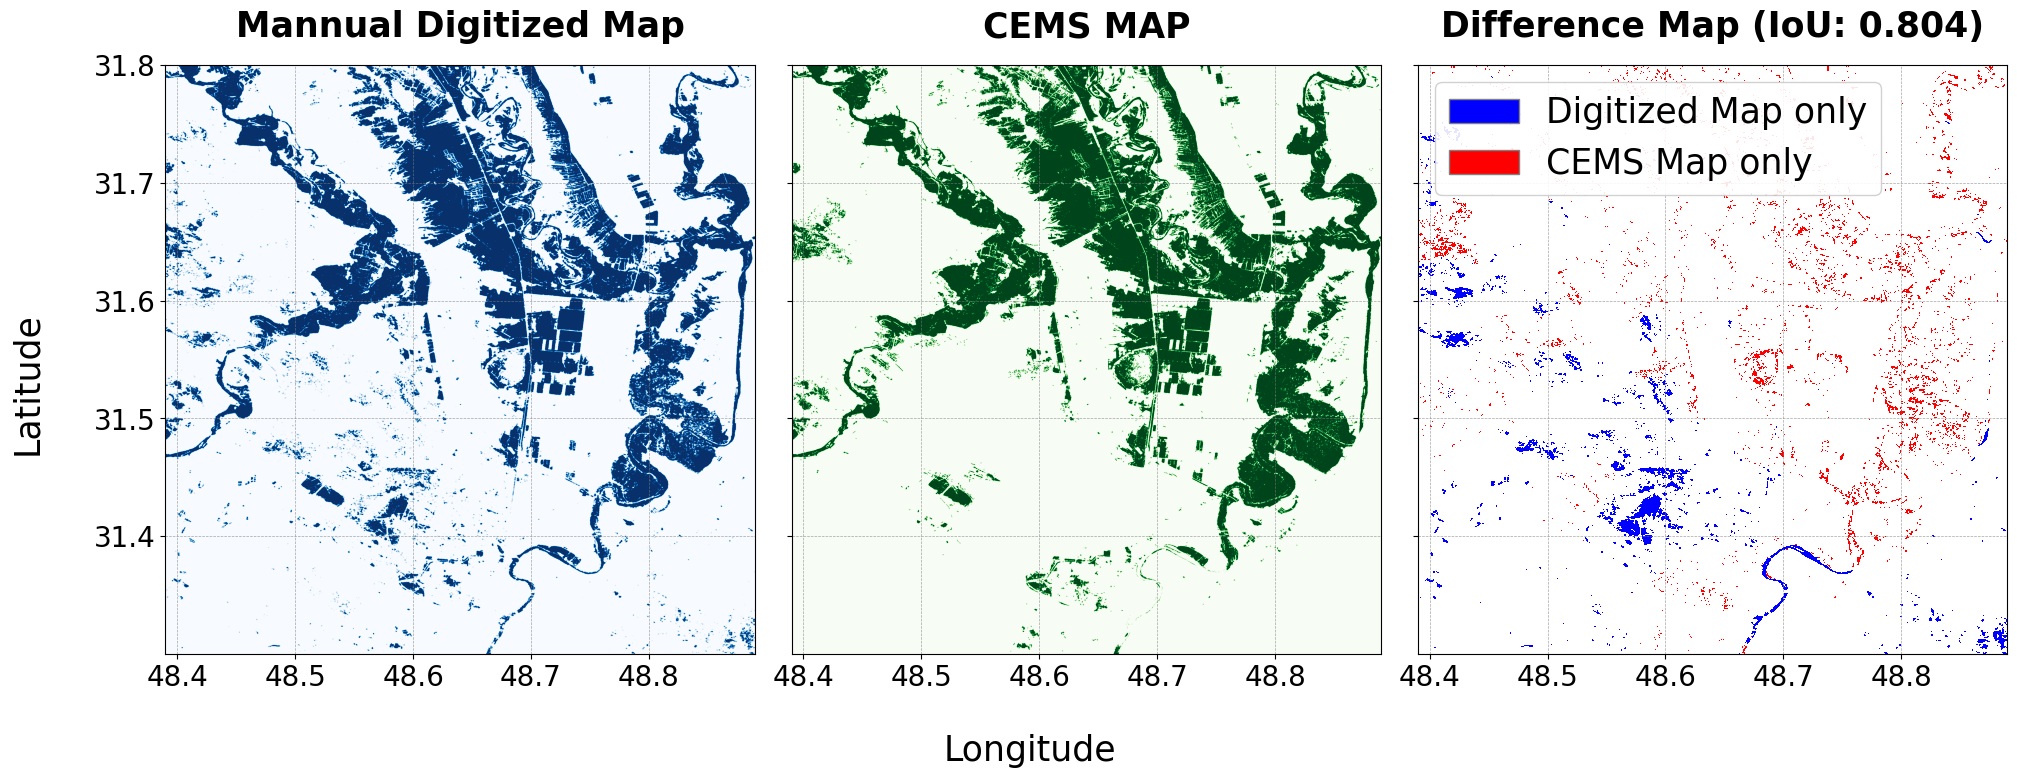

In [4]:
calculate_iou_and_plot_large_fonts(cems_path, digitized_path, save_path)